# Codveda Technologies Internship

## Level 2 - Task 3: Clustering Analysis (K-Means)

### Name:
Ashvini Jadhav

### Domain:
Data Analysis

### Objective:
Perform K-Means Clustering on the cleaned housing dataset to group similar houses into clusters and visualize the results.

## Import Required Libraries

Import the libraries required for clustering, preprocessing, and visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Load the Dataset

Load the cleaned housing dataset.

In [3]:
df = pd.read_csv("cleaned_house_prediction.csv")

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## Dataset Information

Display the dataset shape and information.

In [4]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (506, 14)
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Feature Scaling

Standardize the dataset before applying the K-Means clustering algorithm.

In [5]:
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("Data scaled successfully!")

Data scaled successfully!


## Apply K-Means Clustering

Create and train the K-Means model with three clusters.

In [6]:
from sklearn.cluster import KMeans

# Create K-Means model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
df["Cluster"] = clusters

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Cluster
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0,2
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6,1
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7,2
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4,2
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2,2


## Cluster Distribution

Display the number of records in each cluster.

In [7]:
print(df["Cluster"].value_counts())

Cluster
1    209
0    156
2    141
Name: count, dtype: int64


## Cluster Visualization

Visualize the clusters using Average Number of Rooms (RM) and Median House Value (MEDV).

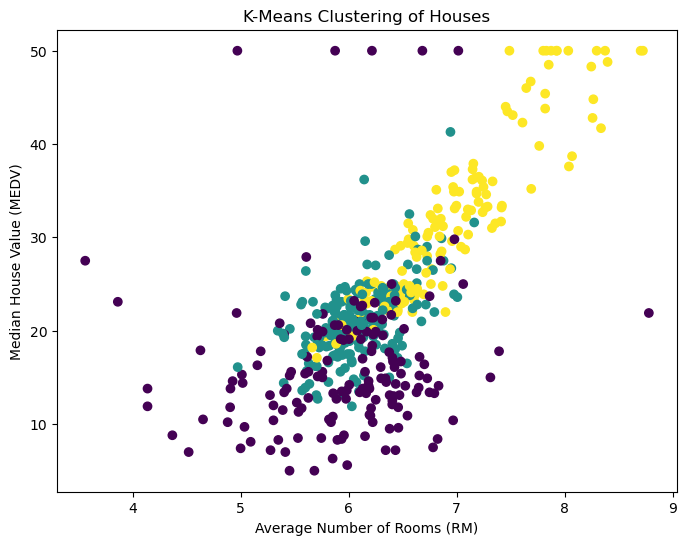

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["RM"], df["MEDV"], c=df["Cluster"])

plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.title("K-Means Clustering of Houses")

plt.show()

## Save Clustered Dataset

Save the clustered dataset as a CSV file.

In [9]:
df.to_csv("clustered_house_prediction.csv", index=False)

print("Clustered dataset saved successfully!")

Clustered dataset saved successfully!


## Cluster Centers

Display the center values of each cluster.

In [10]:
# Display cluster centers
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centers

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,11.052058,1.776357e-14,18.648462,0.076923,0.688237,5.953199,90.733333,1.998293,21.019231,636.282051,19.693590,293.351603,18.996538,16.192949
1,0.376542,2.157895e+00,10.042297,0.071770,0.520014,6.089837,69.257416,3.859259,4.449761,315.832536,18.667464,381.960909,12.379952,21.129665
2,0.181735,3.758156e+01,4.448298,0.056738,0.458352,6.940071,43.047518,5.687750,4.418440,292.900709,16.771631,389.250922,6.039574,31.626950


## Results

- Successfully applied K-Means Clustering.
  
- Number of Clusters: 3

  
- Dataset was standardized before clustering.

  
- Cluster labels were assigned to every house.

  
- A scatter plot was created to visualize the clusters.

  
- The clustered dataset was saved successfully.

## Conclusion

- K-Means Clustering successfully grouped similar houses into three clusters.

- The clusters help identify groups of houses with similar characteristics.
    
- Feature scaling improved clustering performance.
    
- The clustered dataset can be used for further analysis and visualization.